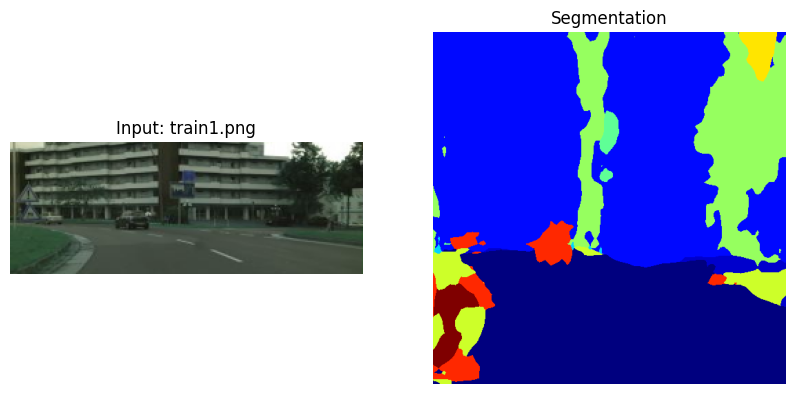

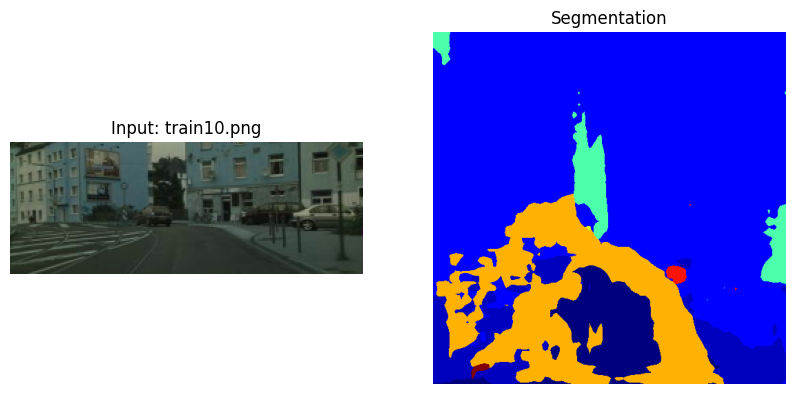

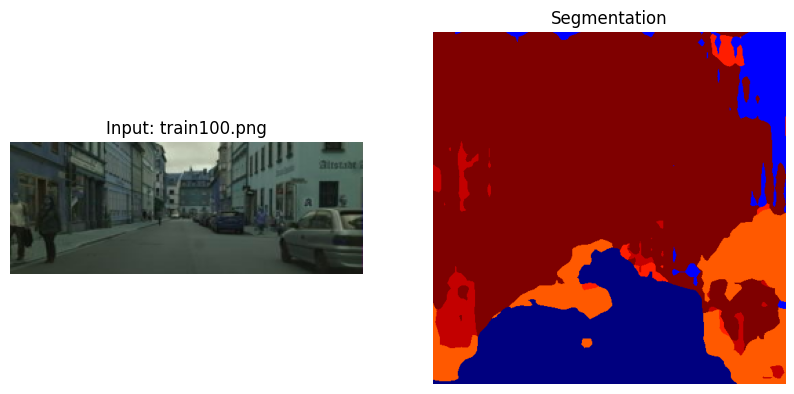

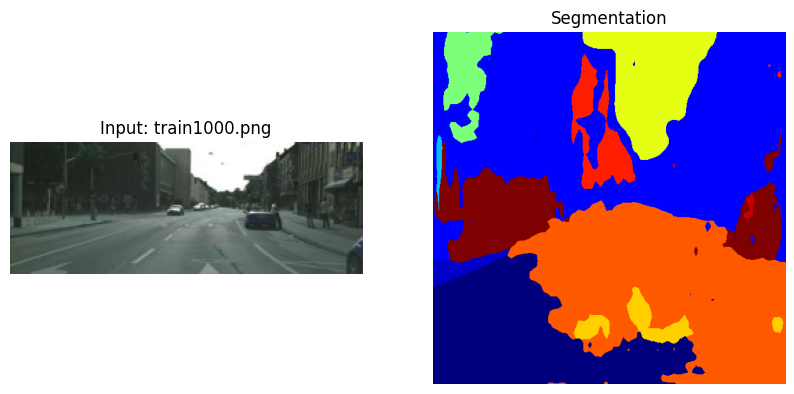

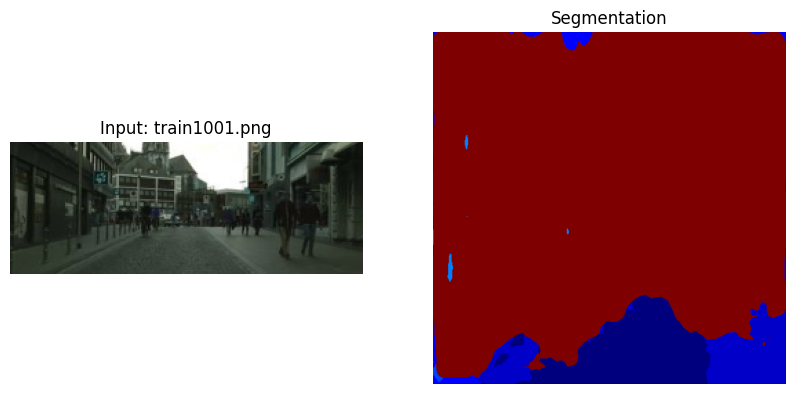

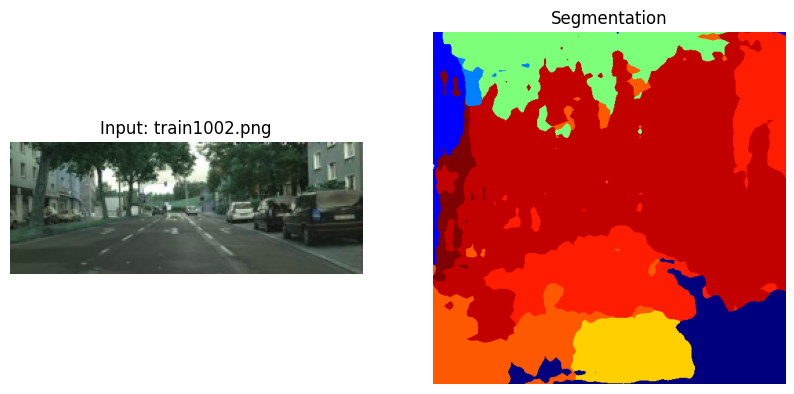

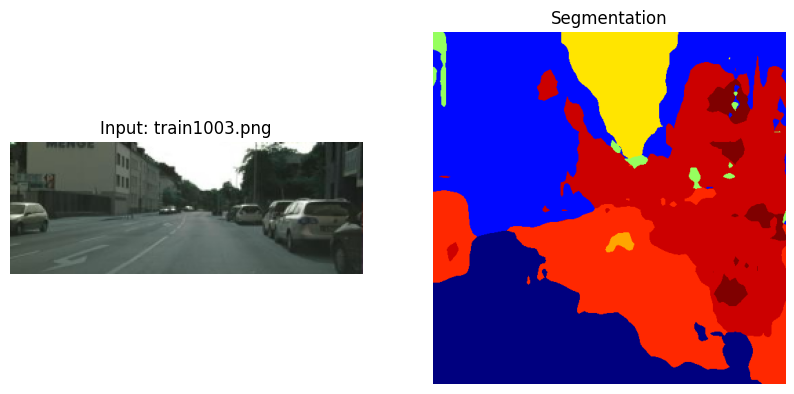

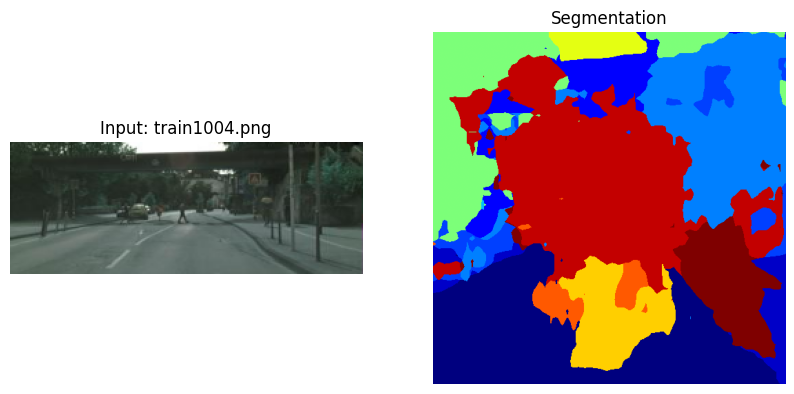

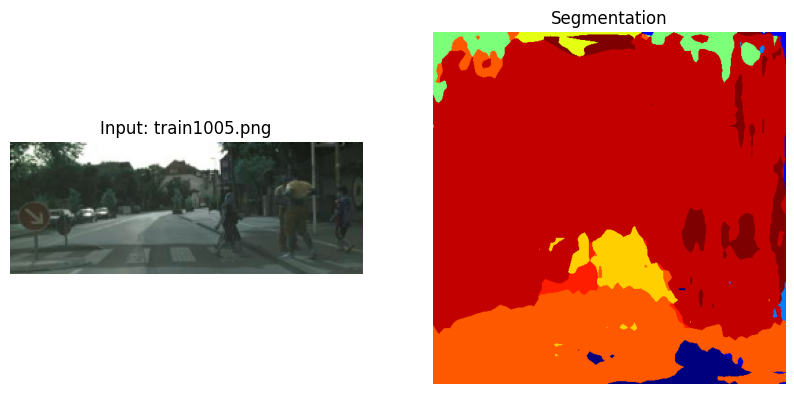

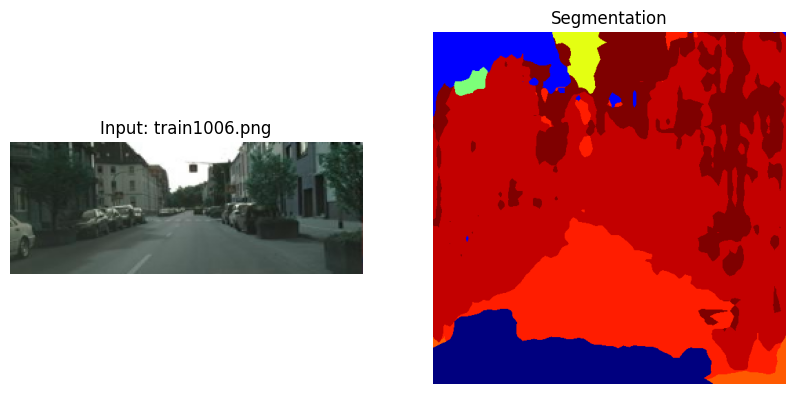

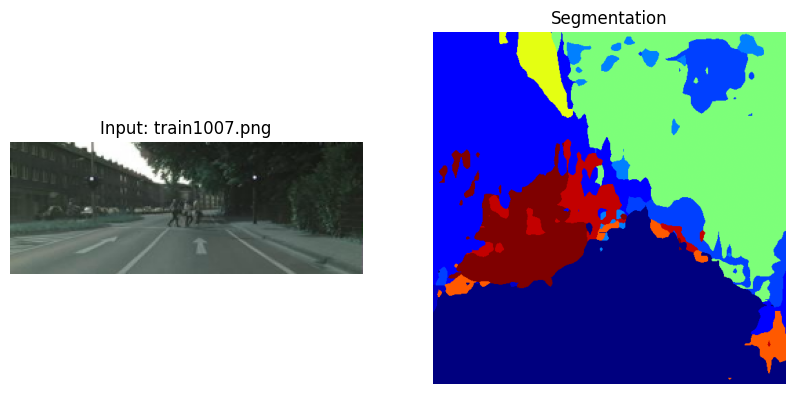

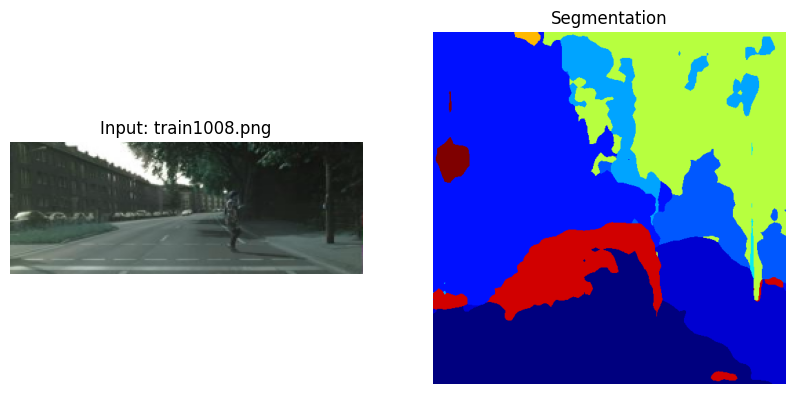

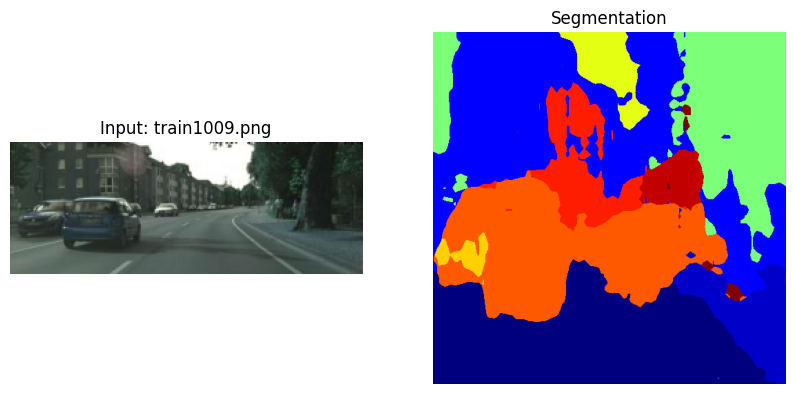

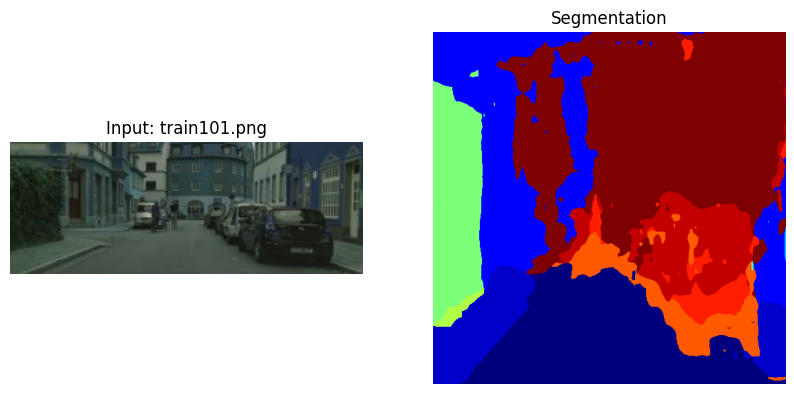

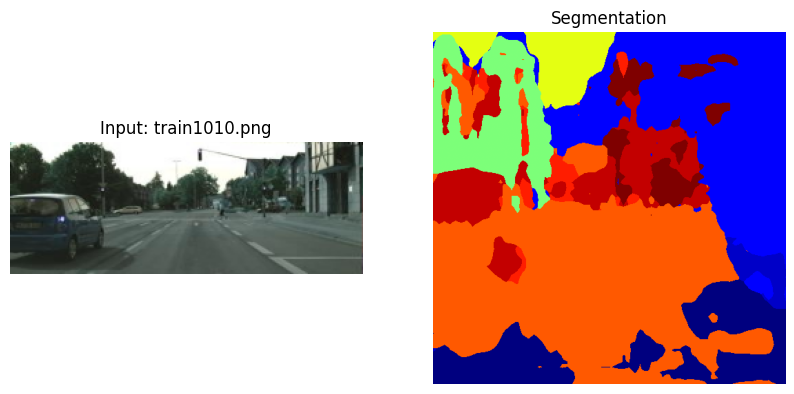

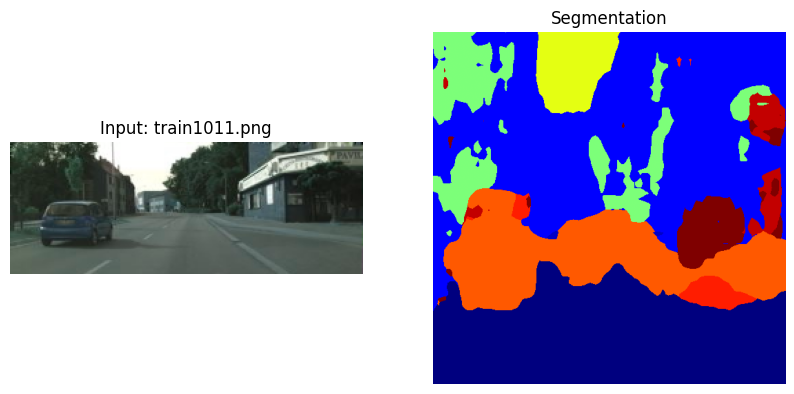

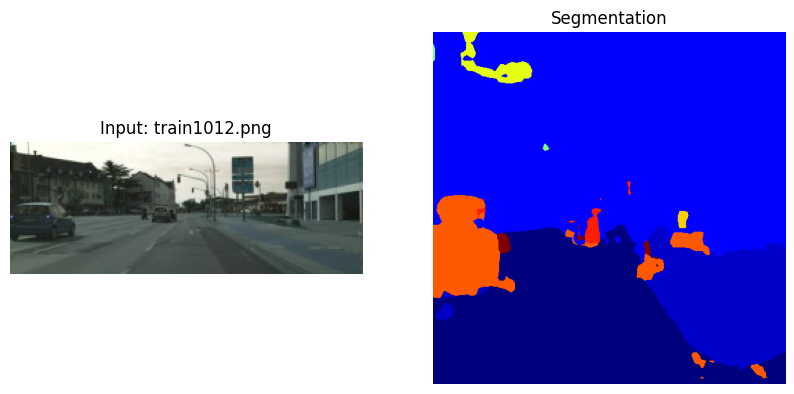

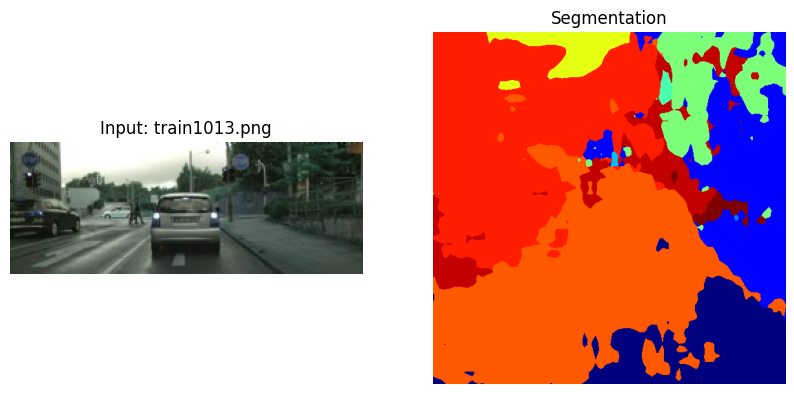

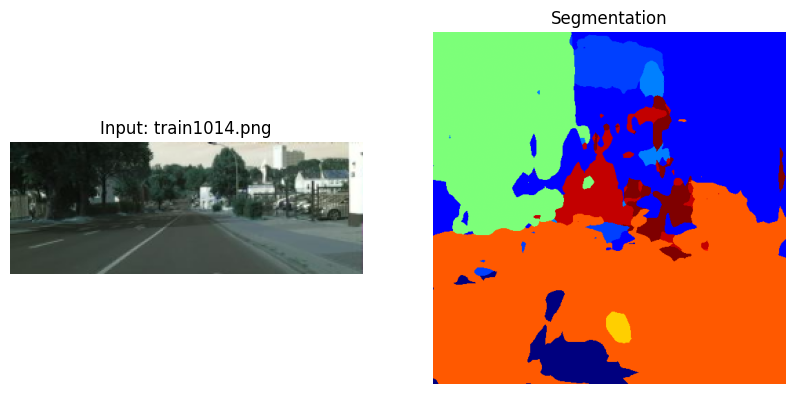

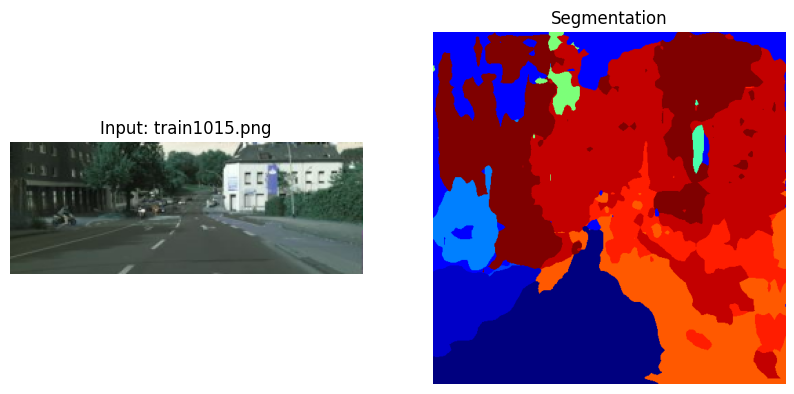

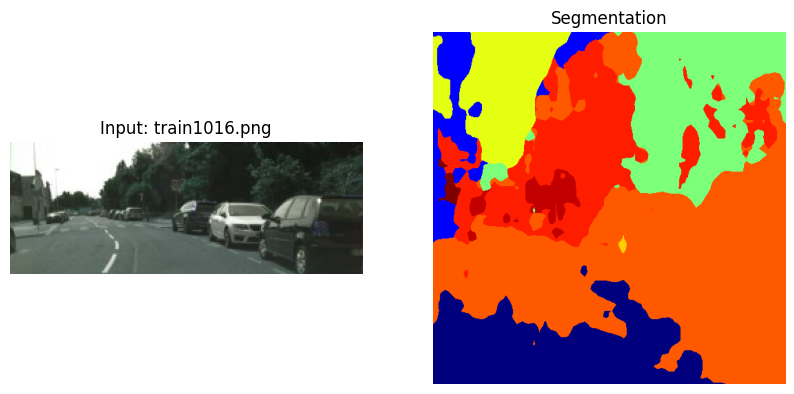

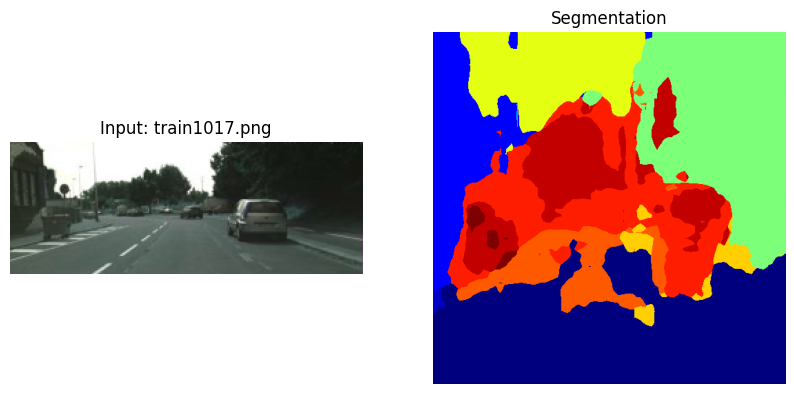

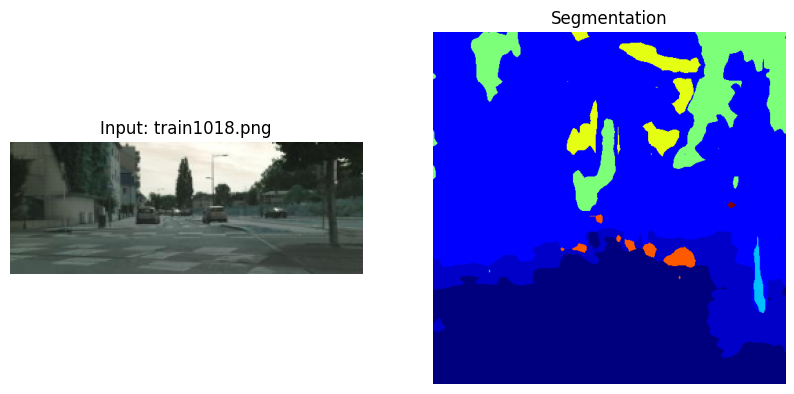

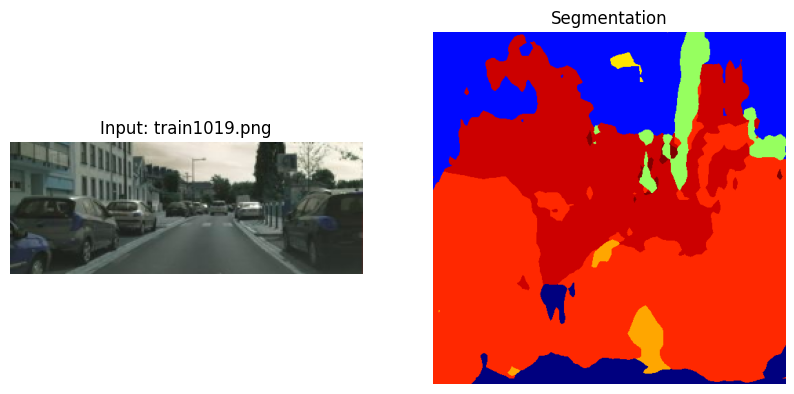

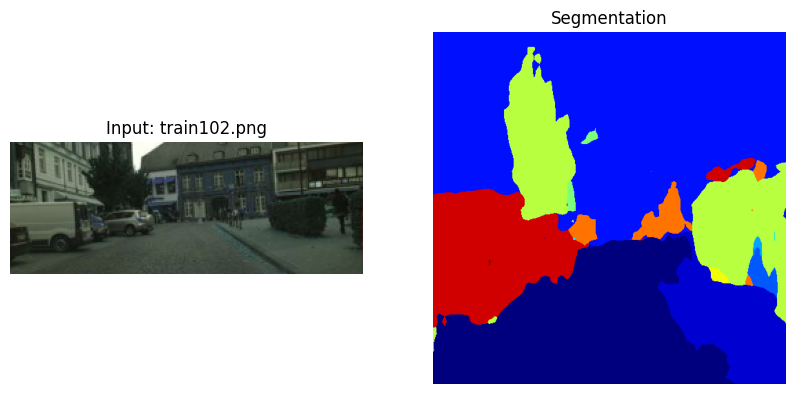

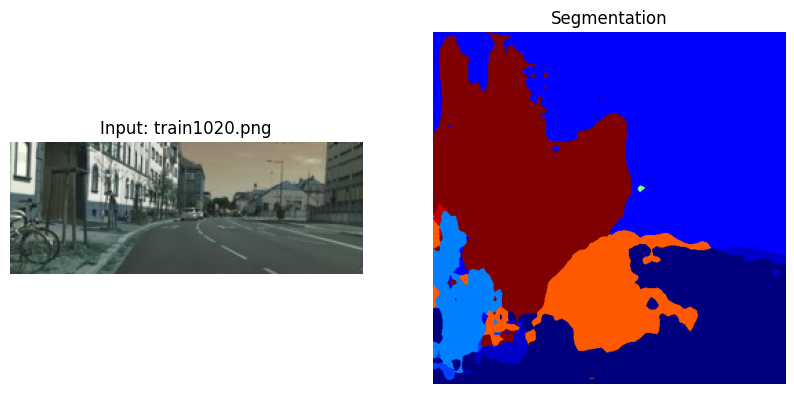

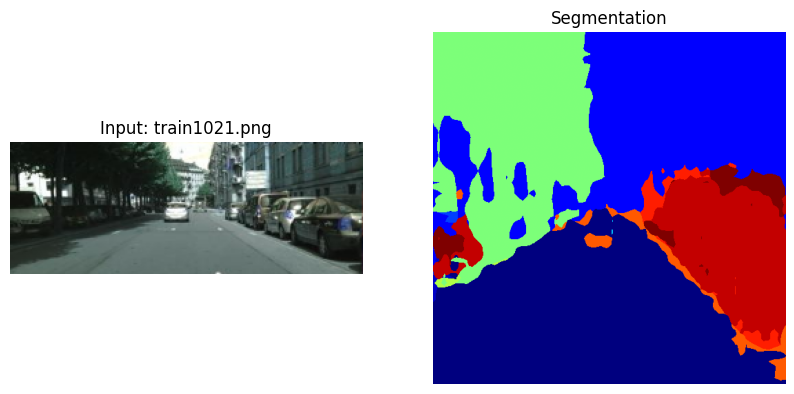

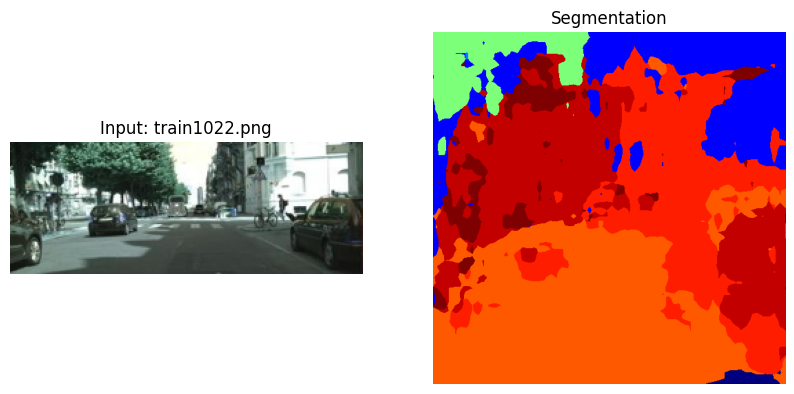

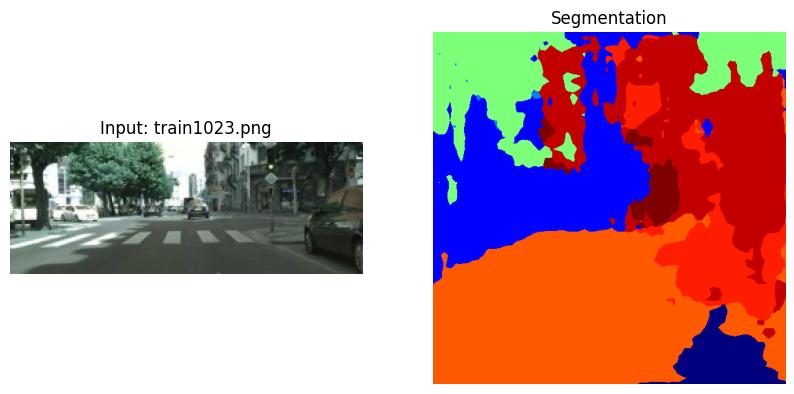

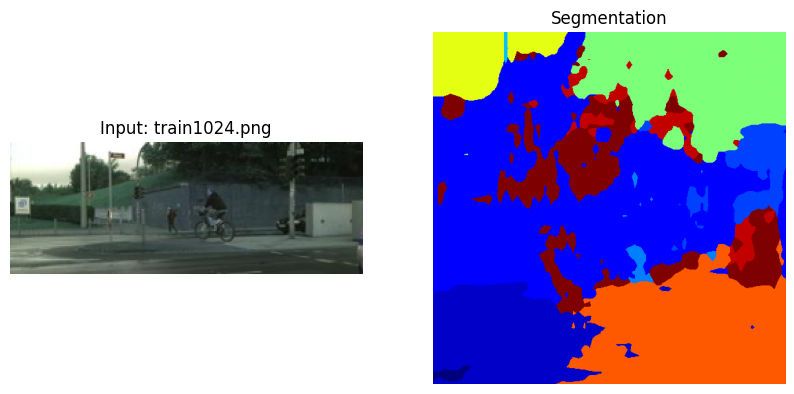

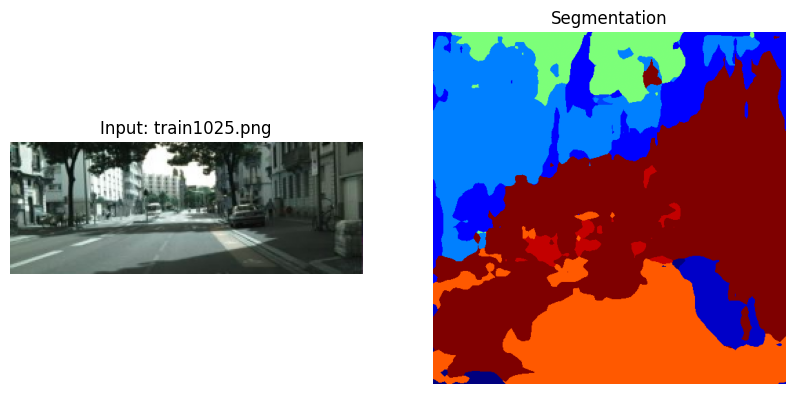

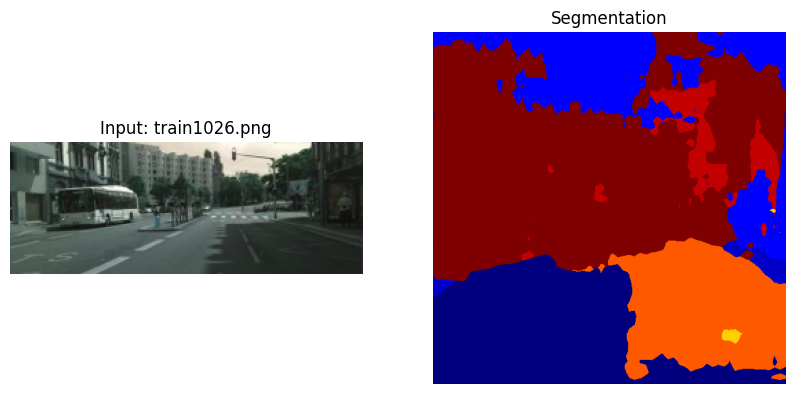

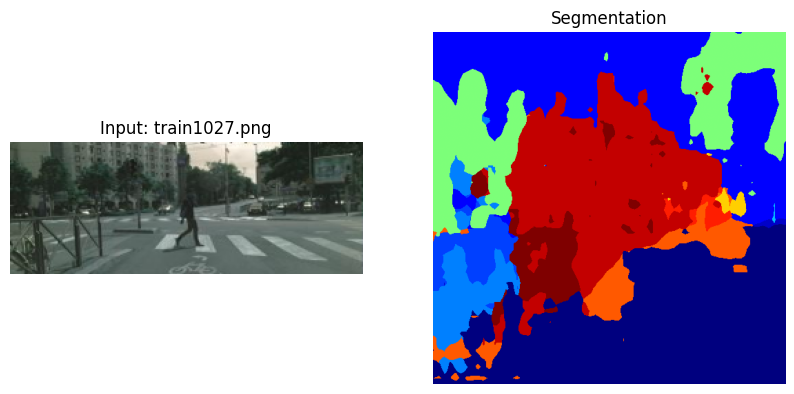

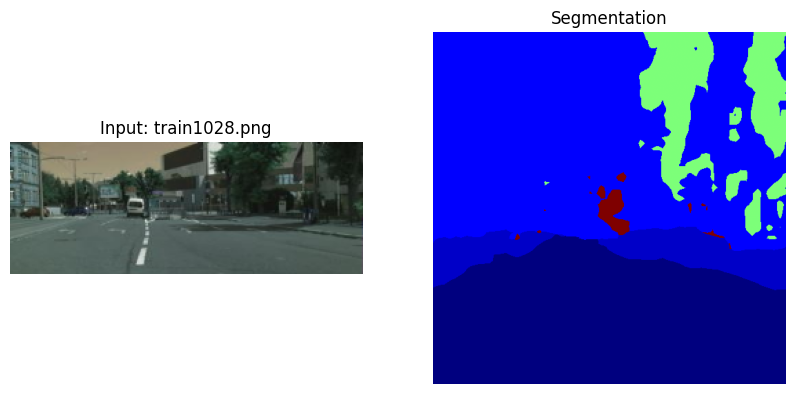

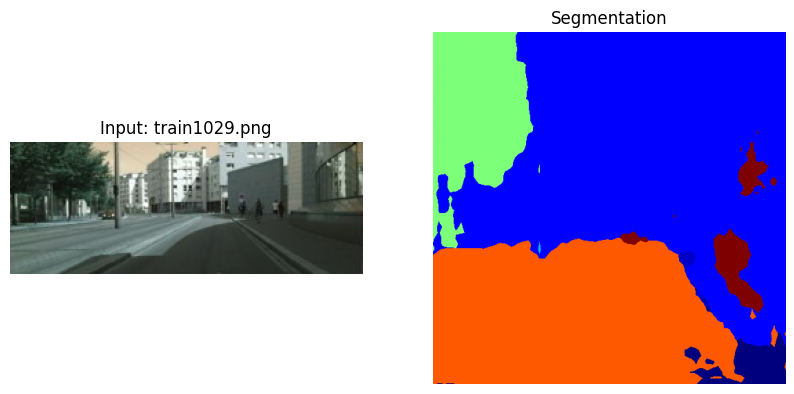

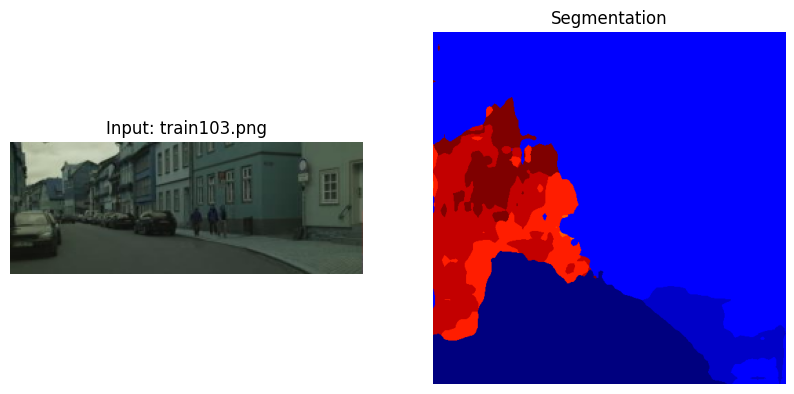

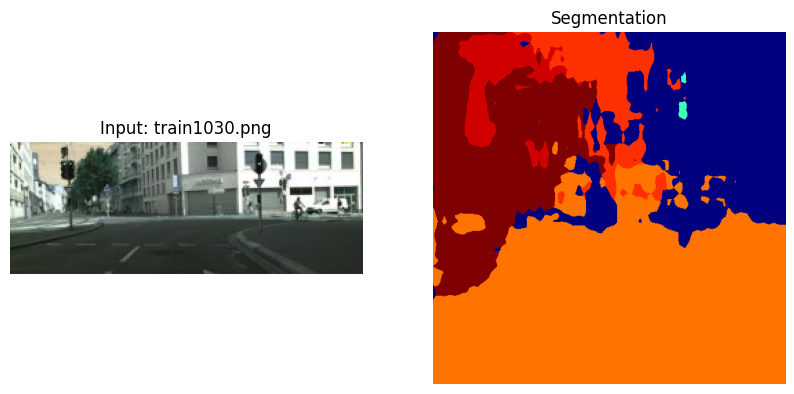

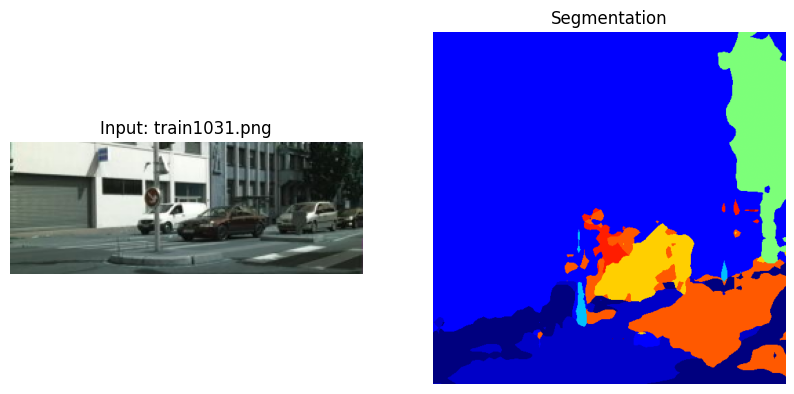

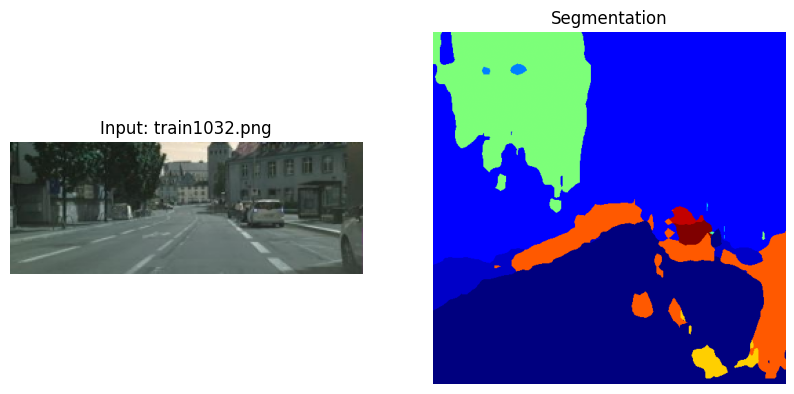

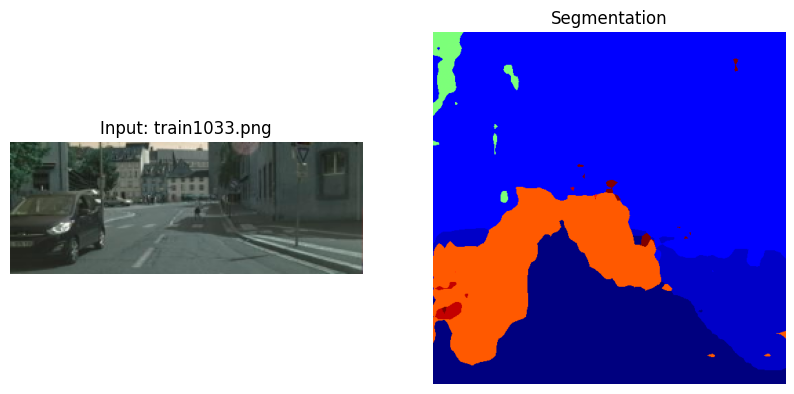

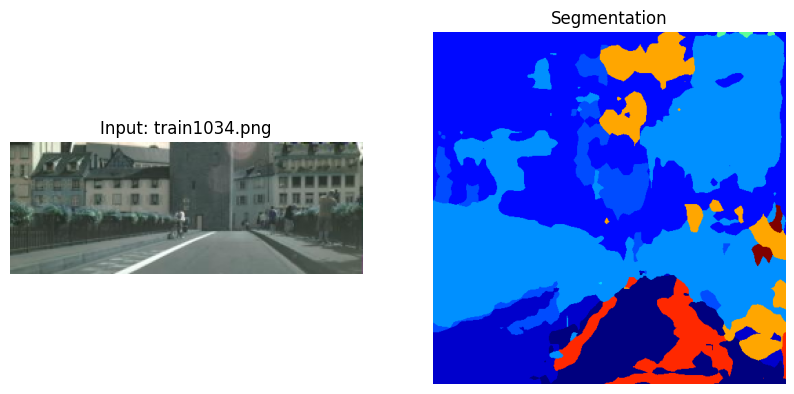

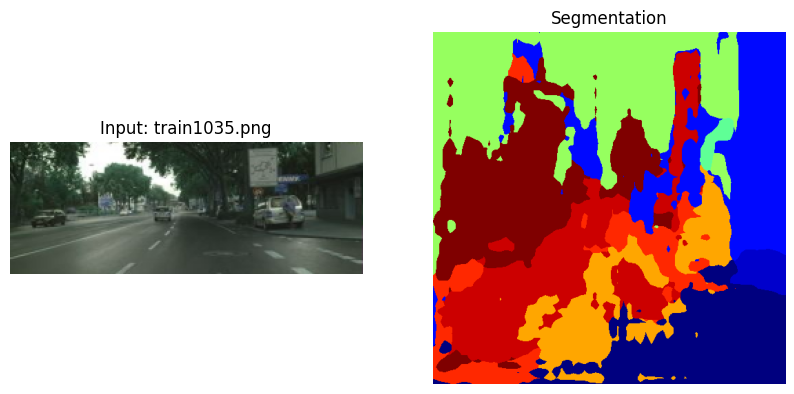

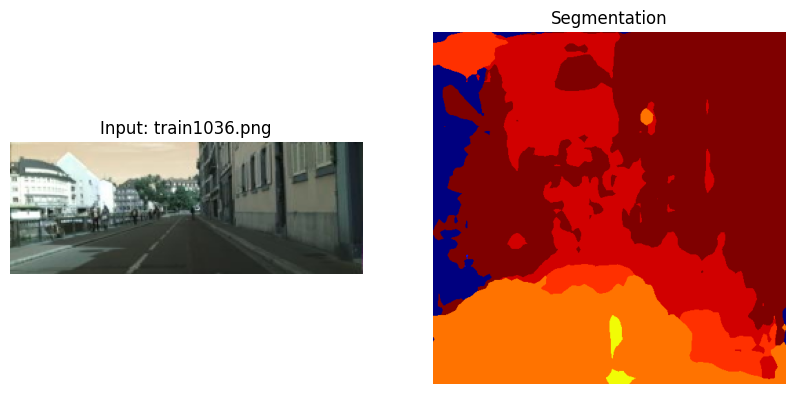

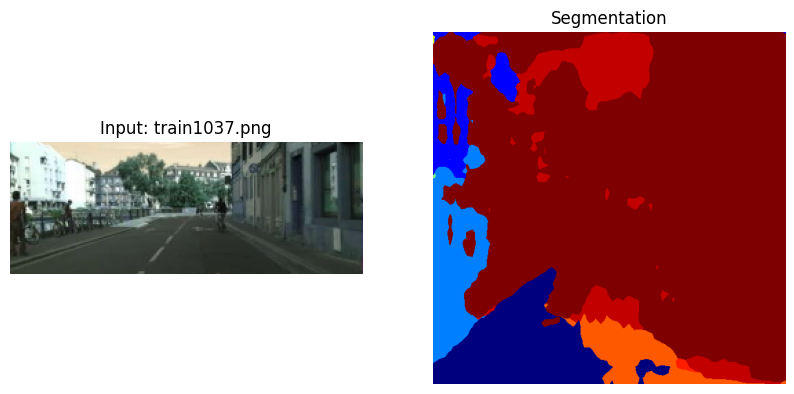

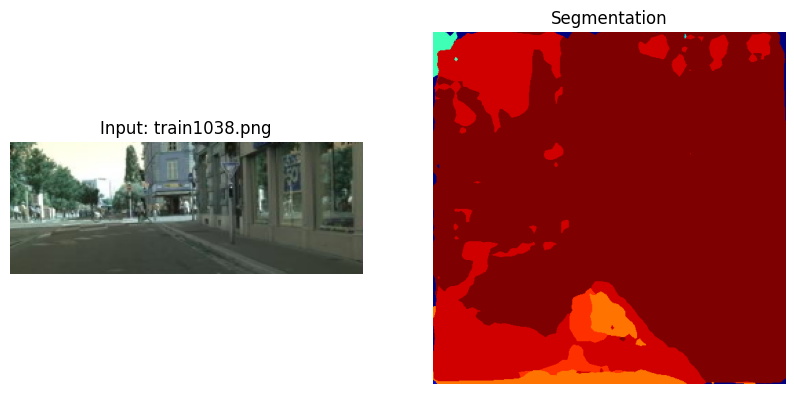

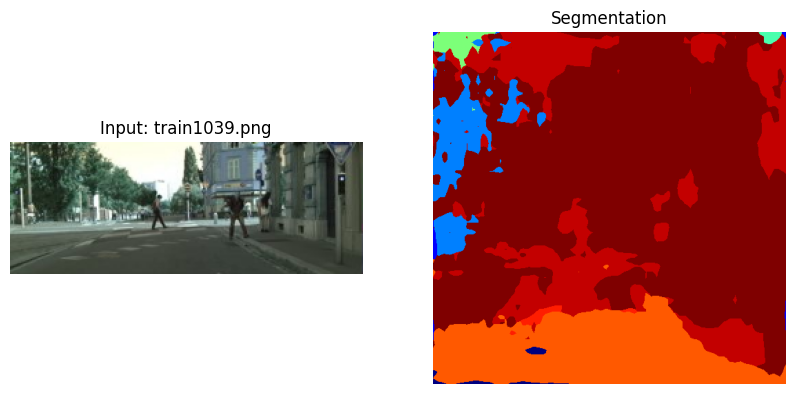

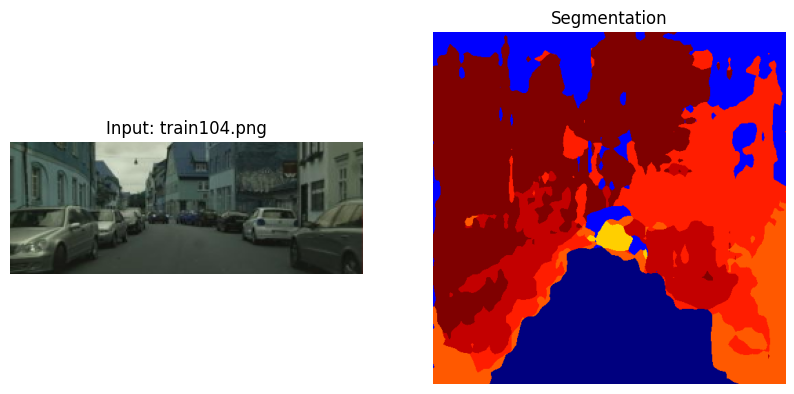

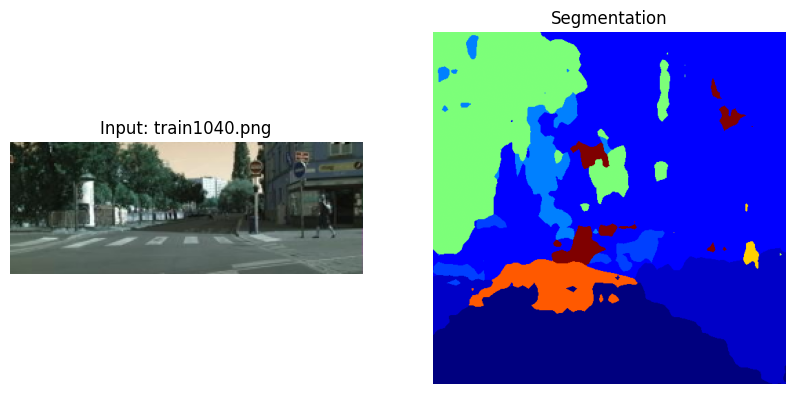

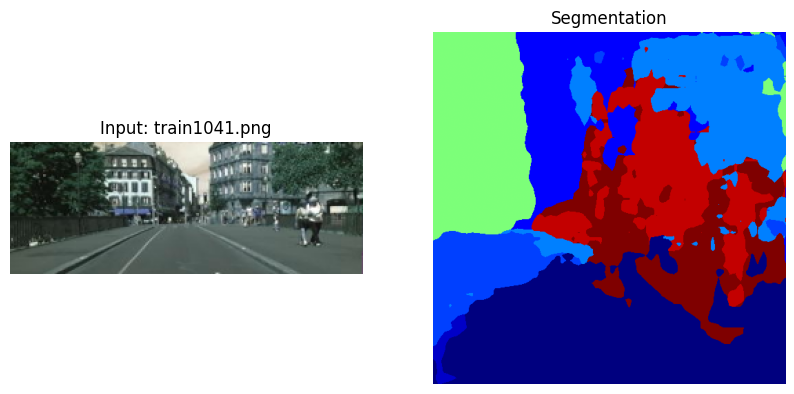

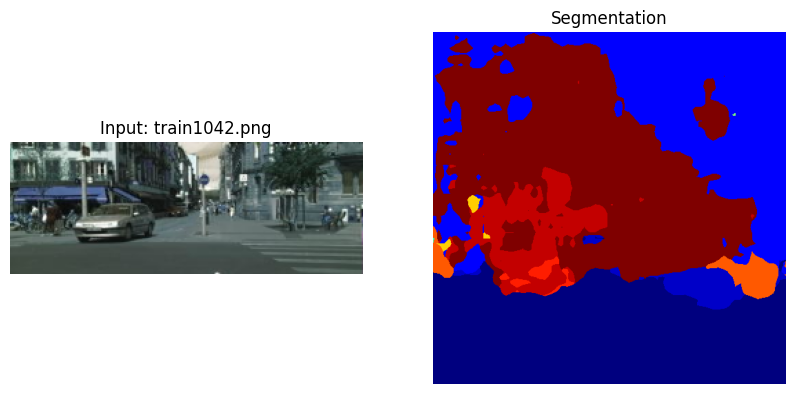

In [1]:
import sys
sys.path.append(r'D:\Documentos\Git\edge-segmentation-lab\src\models')

from fast_scnn import FastSCNN
import torch
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt
import os
import time

model = FastSCNN(num_classes=19)
model.load_state_dict(torch.load(r'D:\Documentos\Git\Fast-SCNN-pytorch\weights\fast_scnn_citys.pth', map_location='cpu'))
model.eval()

# 50 images -> data/train/img
img_dir = r'D:\Documentos\Git\edge-segmentation-lab\data\train\img'
img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:50]

transform = T.Compose([
    T.Resize((512, 512)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

for img_name in img_files:
    img_path = os.path.join(img_dir, img_name)
    image = Image.open(img_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0)
    with torch.no_grad():
        output = model(image_tensor)
    segmentation = output[0].argmax(1).squeeze().cpu().numpy()
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.title(f'Input: {img_name}')
    plt.imshow(image)
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.title('Segmentation')
    plt.imshow(segmentation, cmap='jet')
    plt.axis('off')
    plt.show()
    time.sleep(0.5)  # CPU 50% usage